In [1]:
import os
import sys

import h5py
import numpy as np
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import matplotlib.pyplot as plt
import matplotlib as mpl

sys.path.append(
    "/scratch/mm146/Polarization/polarization/2_simulations"
)

import nuclear_bodies as nb

In [2]:
condition = "complete"
replica = 1

In [3]:
TRAJ_FOLDER = (
    "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/3_sampling"
)
OUTPUT_FOLDER = "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/distances-distributions/data"

NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

if condition not in [
    "control",
    "complete",
    "lamina",
    "nucleolus",
]:
    raise ValueError(
        "Invalid condition. Options are: 'control', 'complete', 'lamina', "
        "'nucleolus'."
    )

print(
    "Computing the distances distributions for chromosome 1",
    flush=True,
)
print(f"\tcondititon: {condition}", flush=True)
print(f"\treplica: {replica}", flush=True)
print("", flush=True)

filepath = os.path.join(
    TRAJ_FOLDER,
    condition,
    str(replica),
    "nucleus_0.cndb",
)

traj = cndbTools()
traj.load(fileName=filepath)

chr_sequence = np.array([x.decode("utf-8")[0] for x in traj.ChromSeq])

num_beads = len(chr_sequence)

i_idx, j_idx = np.triu_indices(num_beads, k=3)

is_A = chr_sequence == "A"
is_B = chr_sequence == "B"
is_N = chr_sequence == "N"


def get_pairs(m1, m2):
    "Logic: (m1[i] AND m2[j]) OR (m1[j] AND m2[i])"

    mask = (m1[i_idx] & m2[j_idx]) | (m1[j_idx] & m2[i_idx])
    return np.column_stack((i_idx[mask], j_idx[mask]))


indices = {
    "AA": get_pairs(is_A, is_A),
    "AB": get_pairs(is_A, is_B),
    "BB": get_pairs(is_B, is_B),
    "AN": get_pairs(is_A, is_N),
    "BN": get_pairs(is_B, is_N),
    "NN": get_pairs(is_N, is_N),
}

Computing the distances distributions for chromosome 1
	condititon: complete
	replica: 1



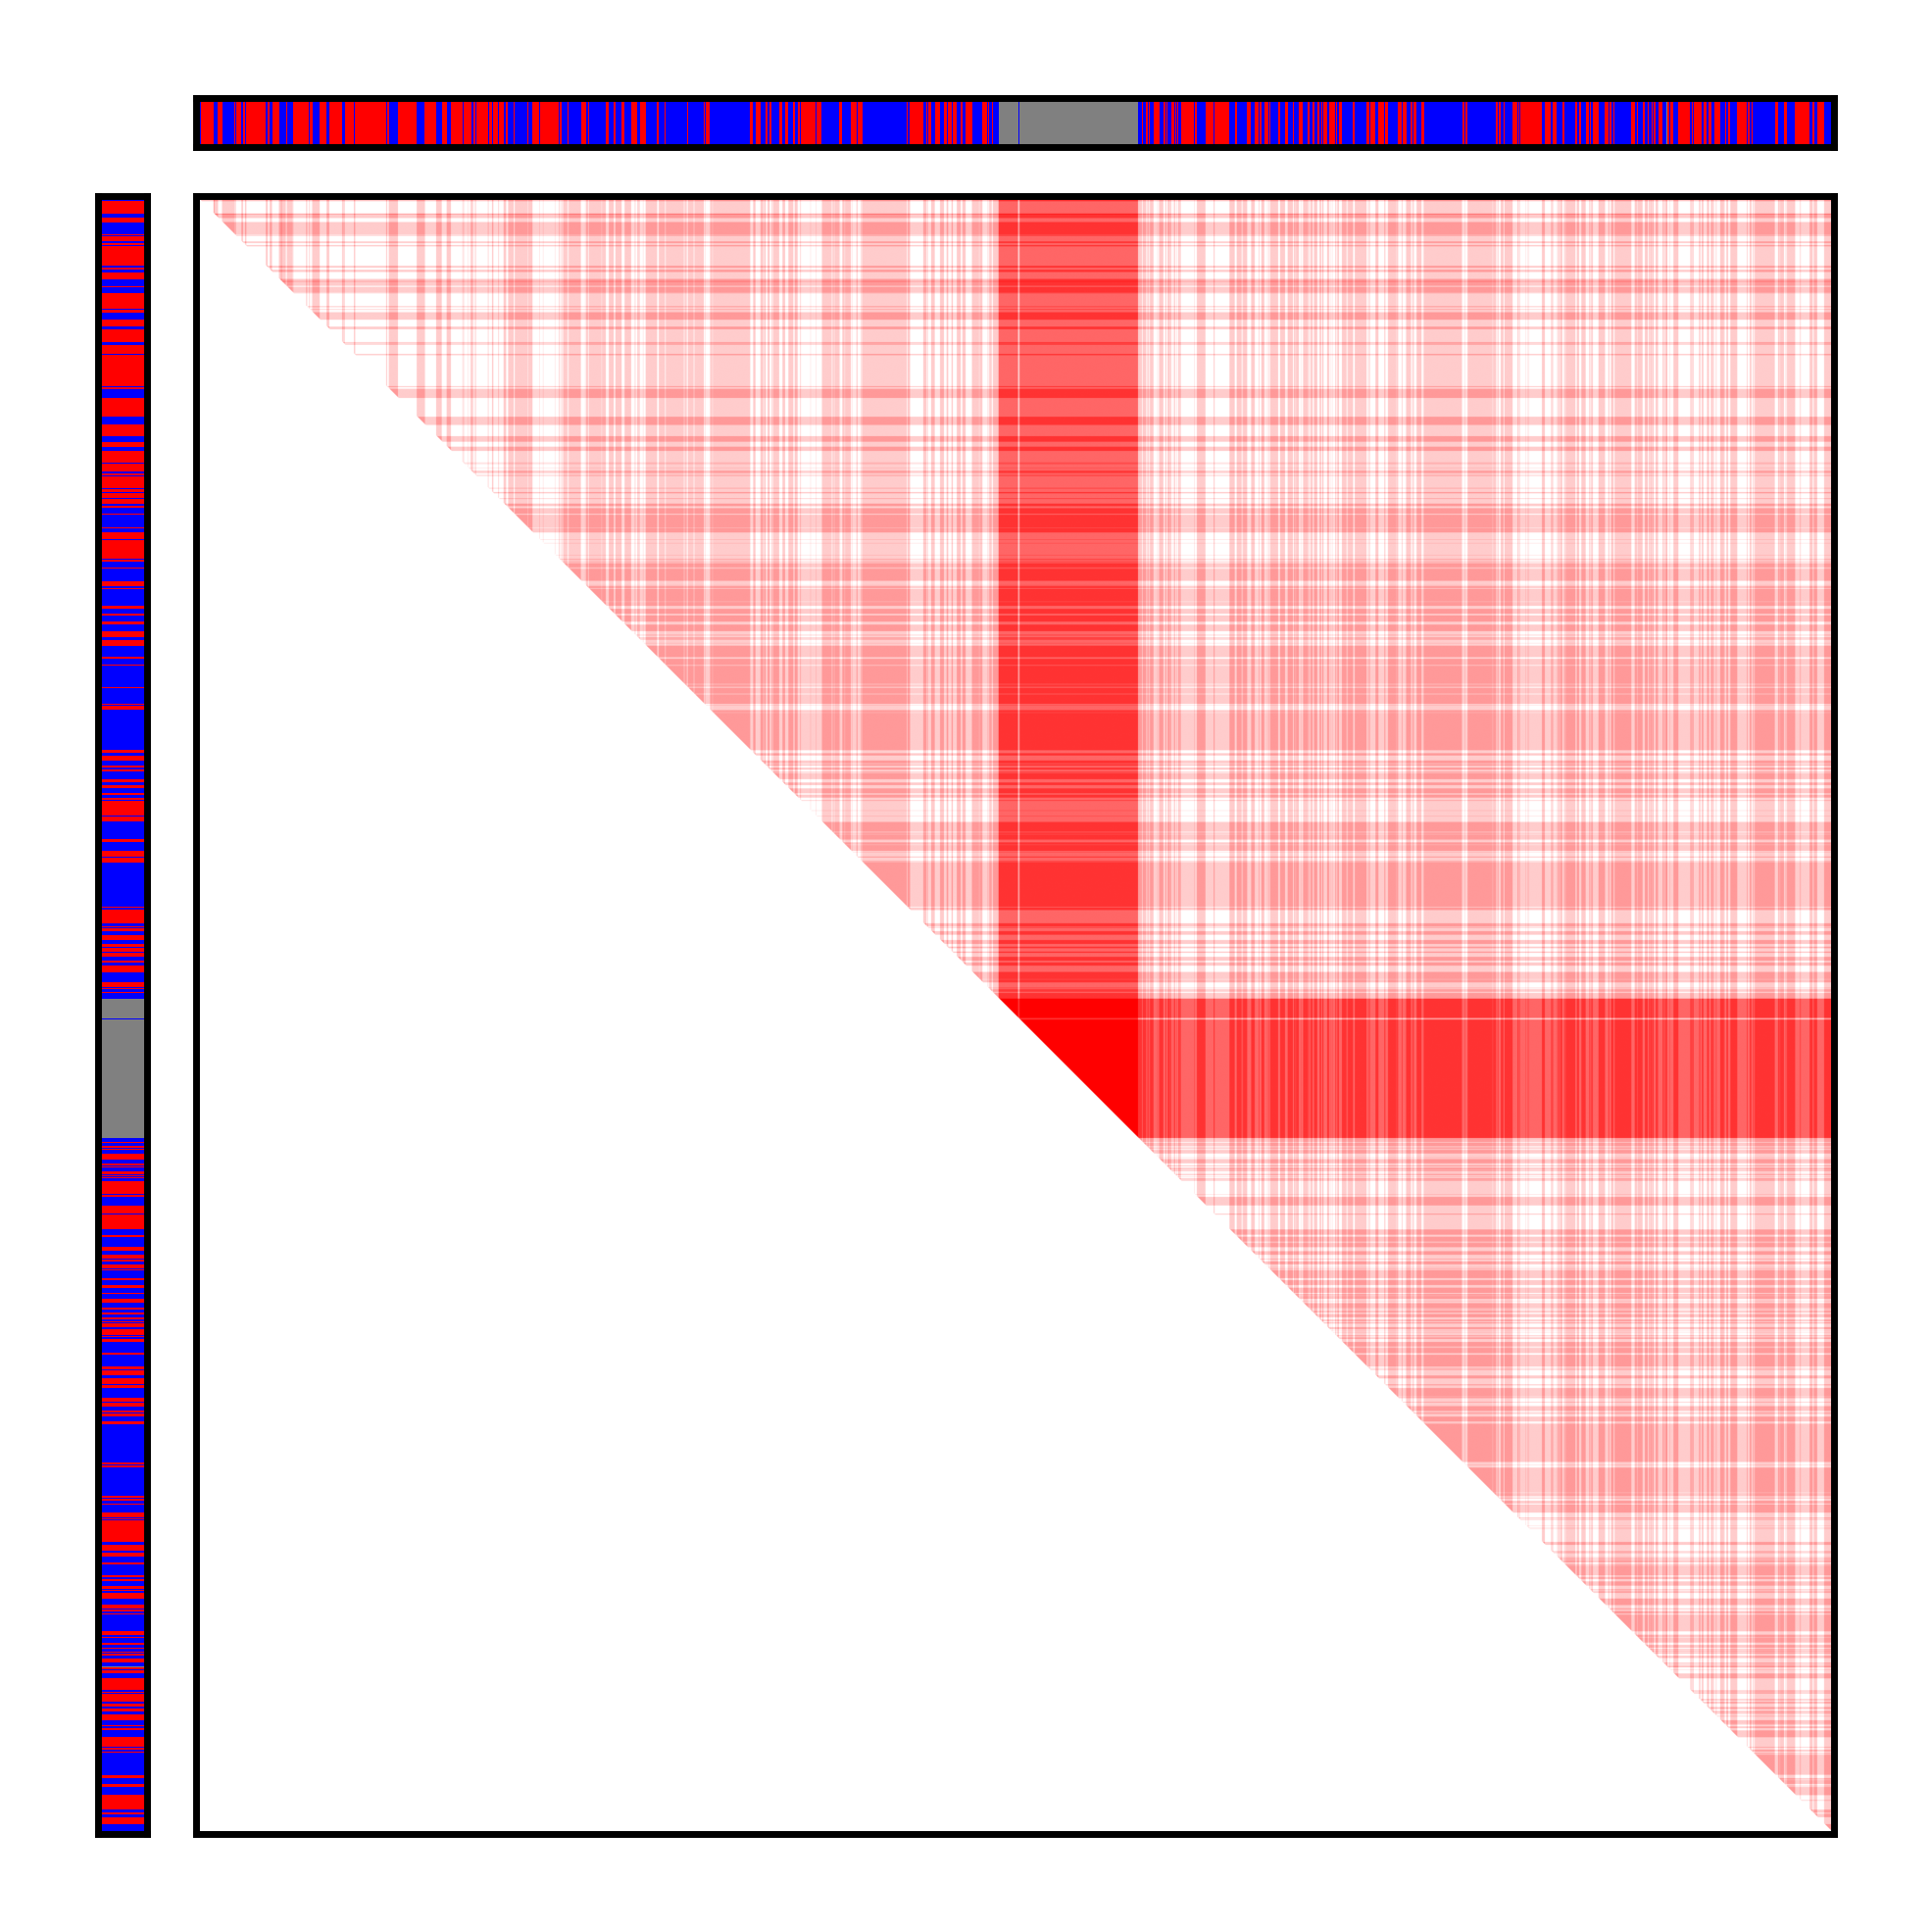

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 2.3))

artist = plotting.PlotContactMap(fig, ax)

matrix = np.zeros((num_beads, num_beads))

value = 0
for tag, pairs in indices.items():
    matrix[pairs[:, 0], pairs[:, 1]] = value
    value += 1

artist.plot_hic(matrix, scale="linear", vmin=0, vmax=5)

compartment_colors = {
    "A": "red",
    "B": "blue",
    "N": "gray",
}
annot_ax = artist.add_compartment_annotations(
    chr_sequence, colors=compartment_colors, loc="left"
)
# annot_ax.set_xlim(-0.5, 0.5)
# annot_ax.set_ylim(-0.5, len(chr_sequence) - 0.5)

annot_ax = artist.add_compartment_annotations(
    chr_sequence, colors=compartment_colors, loc="top"
)
# annot_ax.set_xlim(-0.5, len(chr_sequence) - 0.5)
# annot_ax.set_ylim(-0.5, 0.5)

In [5]:
chr_sequence

array(['B', 'B', 'B', ..., 'A', 'A', 'A'], dtype='<U1')

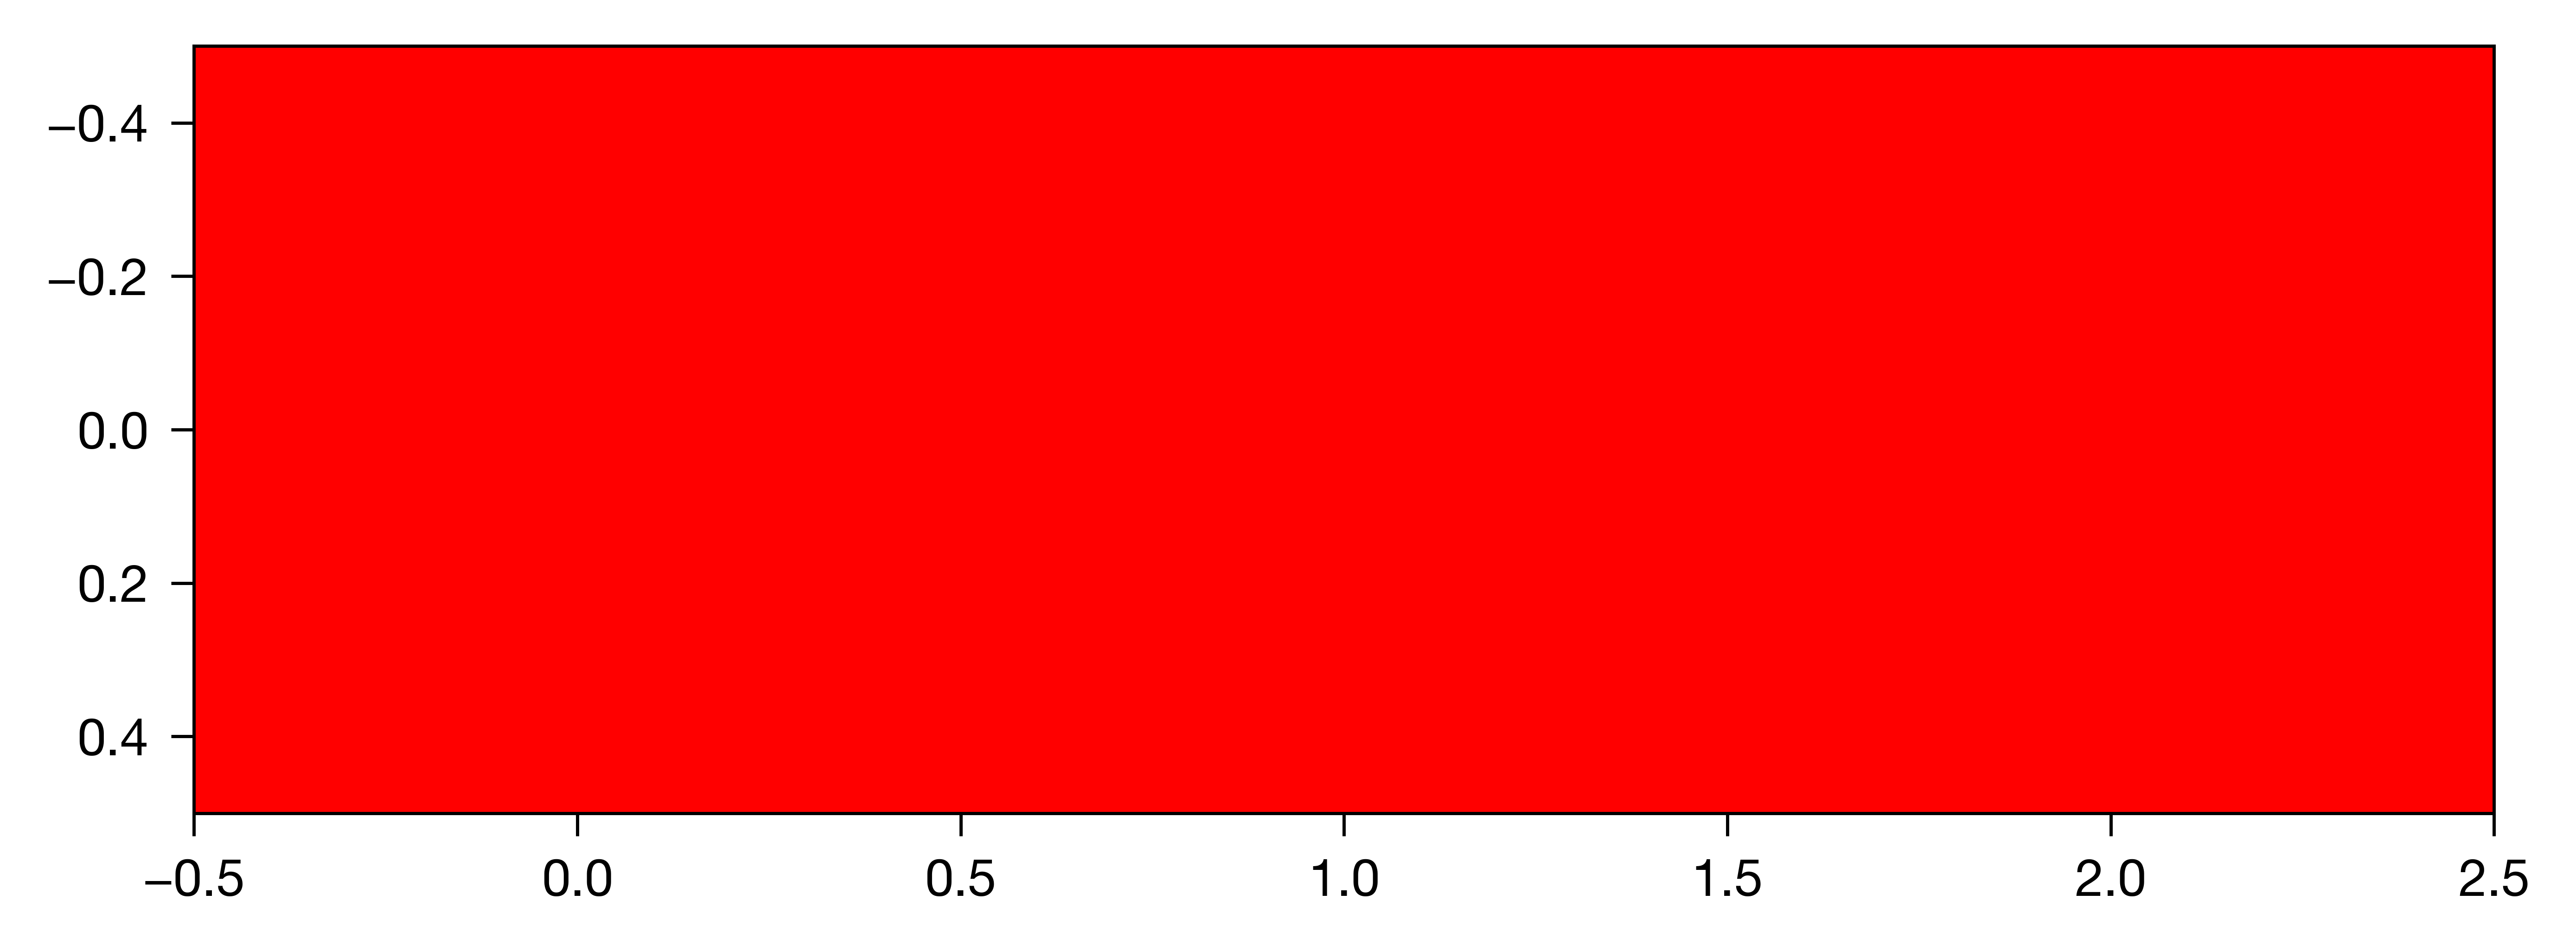

In [6]:
plt.imshow(
    [
        [(1.0, 0.0, 0.0), (1.0, 0.0, 0.0), (1.0, 0.0, 0.0)],
    ]
)